In [14]:
%matplotlib inline
# ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■    Import modules    ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■    


In [15]:
# This script processes wave data from a netCDF file, calculates wave statistics and saves them to a new netCDF fifle.
# First the fuction for wave processing is defined, then the function is called with the input and output file names.

import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import xarray as xr
import matplotlib.pyplot as plt
import sys
from scipy.signal import welch
#sys.path.append(r'C:\Users\dpoppema\OneDrive - Delft University of Technology\Documents\GitHub\HybridDune\Ruben\Pressure_sensors\S1\RBR_05') # to find the puv.py file
import puv 


In [36]:
# Import processed data, find period with (too) long peak periods
input_folder = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Hydrodynamics\Supplementary data\data'
input_file = 'Waves_Hollandse_Kust_Zuid_A.nc'
ncInFile = os.path.join(input_folder, input_file)
t1 = datetime(2024,12,19,0,0)
t2 = datetime(2024,12,23,0,0)

ds = xr.open_dataset(ncInFile)#.sel(t_block=slice(t1, t2))    # dataset with relative pressure
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (t: 17568)
Coordinates:
  * t        (t) datetime64[ns] 141kB 2024-12-01 ... 2025-04-01T23:50:00
Data variables: (12/13)
    H1_10th  (t) float64 141kB ...
    H1_3rd   (t) float64 141kB ...
    H1_50th  (t) float64 141kB ...
    HTE3     (t) float64 141kB ...
    Hm0      (t) float64 141kB ...
    Hmax     (t) float64 141kB ...
    ...       ...
    TE0      (t) float64 141kB ...
    TE3      (t) float64 141kB ...
    TH1_3rd  (t) float64 141kB ...
    Tm02     (t) float64 141kB ...
    Tm02_M   (t) float64 141kB ...
    Tmax     (t) float64 141kB ...

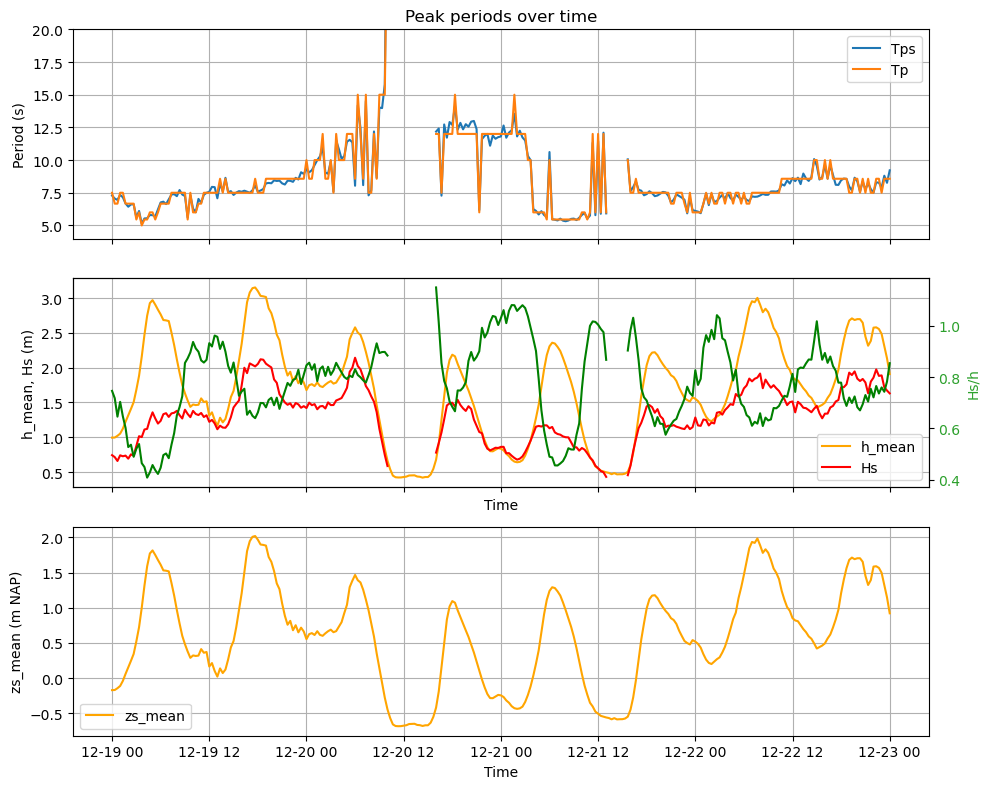

In [16]:
# Import processed data, find period with (too) long peak periods
input_folder = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1'
input_file = 'Pressure sensor S3P3 RBR6 processed data - period 1.nc'
ncInFile = os.path.join(input_folder, input_file)
t1 = datetime(2024,12,19,0,0)
t2 = datetime(2024,12,23,0,0)
#t1 = datetime(2024,12,20,6,0)
#t2 = datetime(2024,12,20,9,0)

ds = xr.open_dataset(ncInFile).sel(t_block=slice(t1, t2))    # dataset with relative pressure
ds = xr.open_dataset(ncInFile).sel(t_block=slice(t1, t2))    # dataset with relative pressure
ds

# Create subplots for Tp/Tps and zs_mean
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot Tp and Tps
axs[0].plot(ds['t_block'], ds['Tps'], label='Tps')
axs[0].plot(ds['t_block'], ds['Tp'], label='Tp')
axs[0].set_ylabel('Period (s)')
axs[0].set_title('Peak periods over time')
axs[0].legend()
axs[0].grid(True)
axs[0].set_ylim(4, 20)

# Plot h, Hs, and h_mean / Hs
axs[1].plot(ds['t_block'], ds['h_mean'], label='h_mean', color='orange')
axs[1].plot(ds['t_block'], ds['Hm0'], label='Hs', color='red')

# Secondary axis (right one)
ax1b = axs[1].twinx()
ax1b.plot(ds['t_block'], ds['Hm0']/ds['h_mean'], label='h_mean / Hs', color='green')
ax1b.set_ylabel(r'Hs/h', color='tab:green')
ax1b.tick_params(axis='y', labelcolor='tab:green')


axs[1].set_xlabel('Time')
axs[1].set_ylabel('h_mean, Hs (m)')
axs[1].legend()
axs[1].grid(True)

# Plot zs_mean
axs[2].plot(ds['t_block'], ds['zs_mean'], label='zs_mean', color='orange')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('zs_mean (m NAP)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Conclusion: 20 dec, block of 6:20 has Tp of 15s

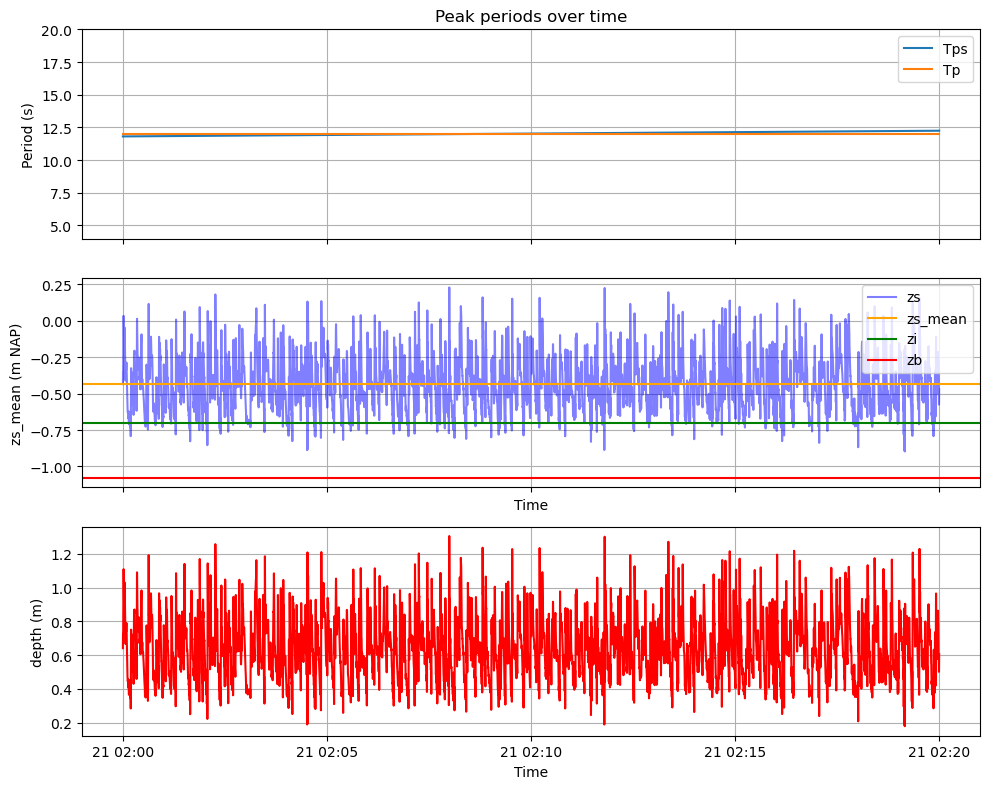

In [34]:
# Import data of specific block, show Zs and depth
input_folder = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1'
input_file = 'Pressure sensor S3P3 RBR6 processed data - period 1.nc'
ncInFile = os.path.join(input_folder, input_file)
t1 = datetime(2024,12,20,6,20)
t2a = datetime(2024,12,20,6,40)
t2b = datetime(2024,12,20,6,40)
t1 = datetime(2024,12,21,2,0)
t2a = datetime(2024,12,21,2,20)
t2b = datetime(2024,12,21,2,20)

ds = xr.open_dataset(ncInFile).sel(t_block=slice(t1, t2a), t_full=slice(t1, t2b))    # dataset with relative pressure
ds = ds.isel(t_full=slice(0,-1))

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot Tp and Tps
axs[0].plot(ds['t_block'], ds['Tps'], label='Tps')
axs[0].plot(ds['t_block'], ds['Tp'], label='Tp')
axs[0].set_ylabel('Period (s)')
axs[0].set_title('Peak periods over time')
axs[0].legend()
axs[0].grid(True)
axs[0].set_ylim(4, 20)

ds = ds.isel(t_block=0)

# Plot surface, bed, instrument [NAP]
dy = 0 #.0875
axs[1].plot(ds['t_full'], ds['zs']+dy, label='zs', color='blue', alpha=0.5)
axs[1].axhline(ds['zs_mean'].values+dy, color='orange', linestyle='-', label='zs_mean')
axs[1].axhline(ds['zi'].values+dy, color='green', linestyle='-', label='zi')
axs[1].axhline(ds['zs_mean'].values-ds.h_mean.values+dy, color='red', linestyle='-', label='zb')


axs[1].set_xlabel('Time')
axs[1].set_ylabel('zs_mean (m NAP)')
axs[1].legend()
axs[1].grid(True)

# Plot depth
axs[2].plot(ds['t_full'], ds['h'], label='zs', color='red')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('depth (m)')
axs[2].grid(True)

# Zoom in on specific time window
t1 = ds['t_full'].values[0]
dt = np.timedelta64(2, 'm')
#axs[1].set_xlim(t1, t1+dt)
#axs[2].set_xlim(t1, t1+dt)

plt.tight_layout()
plt.show()



In [35]:
ds.zs_mean.values+ds.Hm0.values/2

np.float64(-0.09580542045645613)

In [6]:
input_folder = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\QC\Deployment period 1'
input_file = 'Pressure sensor S3P3 RBR6 p_rel - period 1.nc'
t1 = datetime(2024,12,20,6,20)
t2 = datetime(2024,12,20,6,40)

# ### INPUT/OUTPUT FILES, SETTINGS ################################################################################################################################
# Folders, file names -------------------
ncInFile = os.path.join(input_folder, input_file)

# Physical constants -------------------
rho = 1027 #kg/m3, for seawater at 9C, avg temp at HKZ measurement station
g = 9.8125  # value Zandmotor

# Settings spectral analysis: segments (Welch method) -------------------
p_blocks = 20          # number of segments within block, for the Welch method
D_length = 1200        # Duration of block in seconds (20 minutes)
D_length_s = '1200s'   # Duration of block in seconds (20 minutes). (same as above, but as string for xarray)

# ### IMPORT DATA, RESAMPLE TO 2D  ################################################################################################################################
# NB: 3 datasets are created: ds0 (imported data), ds_2D (data reshaped to blocks of (e.g.) 20 minutes, and some temporary variables 
# that won't be saved), and ds_out (final output dataset, with wave statistics and 1D timeseries of water level, depth)

# load the data from netcdf ---------------------------------------------------
ds0 = xr.open_dataset(ncInFile)    # dataset with relative pressure
ds0 = xr.open_dataset(ncInFile).sel(t=slice(t1, t2))    # dataset with relative pressure
ds0 = ds0.isel(t=slice(0,-1))

# frequency resolution in fourier space --------------------------------------------
fresolution = p_blocks / D_length                   # Frequency resolution is 1/T_segment = n_segments / T_block
nperseg = D_length * ds0.sf.values / p_blocks - 0.5 # dim should be len(ds.f); whelch has (nperseg/2 +1)
#nperseg = D_length * ds0.sf.values / p_blocks # dim should be len(ds.f); whelch has (nperseg/2 +1)

# Make 2D data array with one column per burst -----------------------------------
pt = ds0.p_rel.values                               # relative pressure, pAir subtracted
nSamples = len(pt)
dt = ds0.isel(t=1).t - ds0.isel(t=0).t

burstDuration = pd.Timedelta(D_length_s)            # Burst duration (1200 seconds = 20 minutes)
burstLength = int(burstDuration / dt)
nBursts = int(np.floor(nSamples / burstLength))

pt = pt[:nBursts * burstLength]
t_full = ds0.t.values[:nBursts * burstLength]       # time vector for all samples, up to the last complete burst. skip incomplete burst at end
t_block = t_full[::burstLength]                     # take every nth step, so t = t0 of every burst

N = (ds0.t.values[:burstLength] - ds0.t.values[0]) / np.timedelta64(1, 's')  # New dimension: time in seconds since start of burst

# Cast pressure into a 2D array 
ds_2D = xr.Dataset(data_vars={},                    # Temporary 2D dataset, with cooridnates t (no. of blocks), N (obs within block)
                coords={'t_full': t_full,                
                        't_block': t_block,
                        'N': N,
                        'f': np.arange(0, ds0.sf.values / 2, fresolution)})
ds_2D['p'] = (('t_block', 'N'), pt.reshape((nBursts, burstLength)))      # relative pressure, pAir subtracted


# make a new dataset that has an extra dimension to accomodate for the frequency axis ----------------------------------
ds_out = xr.Dataset(data_vars={},
                coords={'t_full': t_full,                  
                        't_block': t_block,
                        'f': np.arange(0, ds0.sf.values / 2, fresolution)})

# # put all variables in this new dataset
ds0 = ds0.sel(t=slice(t_full[-1]))  # Make copy of ds0, with only complete blocks (i.e., 41 minutes data, 20min blocks, than take first 40 min)
ds_out.attrs = ds0.attrs
for key in ds0.data_vars:
    ds_out[key] = ds0[key]


# Drop raw pressure, rename p_rel to p
ds_out['p'] = ('t_full',ds_out.p_rel.data)          # renaming p_rel to p 
ds_out['p'].attrs = ds0['p_rel'].attrs              # copying metadata
ds_out = ds_out.drop_vars('p_rel')                  # dropping the old p_rel variable
ds_out = ds_out.drop_vars('p_abs')                  # dropping the old p_abs variable
ds_out = ds_out.drop_dims('t')                      # plus dropping dimension t (now renamed to t_full)

# ■■■■■■■■■■ raw pressure
f, psd1 = welch(ds_2D['p'].values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# ### APPLY BANDPASS FILTER, DEAL WITH TIME-VARYING BED/INSTRUMENT LEVELS AND COMPUTE BLOCK-AVERAGED WATER DEPTH ################################################################

# pressure: bandpass filtering  --------------------------------------------------------
ufunc_bandpass    = lambda x: puv.band_pass_filter2(ds0.sf.values, x, fmin=0.004, fmax=1.5)
ufunc_bandpass_IG = lambda x: puv.band_pass_filter2(ds0.sf.values, x, fmin=0.004, fmax=0.05)
ufunc_bandpass_WW = lambda x: puv.band_pass_filter2(ds0.sf.values, x, fmin=0.05, fmax=1.5)

ds_2D['p'] = xr.apply_ufunc(ufunc_bandpass, 
                        ds_2D['p'],
                        input_core_dims=[['N']],
                        output_core_dims=[['N']],
                        vectorize=True)
ds_2D['p_IG'] = xr.apply_ufunc(ufunc_bandpass_IG, 
                        ds_2D['p'],
                        input_core_dims=[['N']],
                        output_core_dims=[['N']],
                        vectorize=True)

# ■■■■■■■■■■ bandpass filtered p
f, psd2 = welch(ds_2D['p'].values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# # Time-varying bed and instrument level --------------------------------------------------------
# Define z_bed_obs and t_bed_obs for RBR6 
t_zb_obs = pd.to_datetime(ds0.t_zb.values)
t_block2 = pd.to_datetime(t_block)  # Convert to pandas datetime for consistency
zb_obs = ds0.zb.values

# Interpolate z_bed_obs to z_bed_block for time t_block
zb_block = np.interp(t_block2, t_zb_obs, zb_obs)            # Interpolate bed level to block time vector
zb_block2 = np.reshape(zb_block,(len(zb_block),1))          # reshape from row to column vector for compatibility with p

# repeat for z_i. Only for file no. 3 (RBR4), the rest had constant bed level, so simply repeat bedlevel there
if np.size(ds0.zi.values) > 1: # If the instrument was moved, so time-varying zi
    t_zi_obs = pd.to_datetime(ds0.t_zi.values)
    zi_obs = ds0.zi.values

    # 'Interpolate' zi to t_block: use previous known value (so step-wise, not linear interpolation)
    idx = np.searchsorted(t_zi_obs, t_block2, side='right') - 1
    idx = np.clip(idx, 0, len(zi_obs) - 1)                  # Ensure indices are within bounds
    zi_block = zi_obs[idx]
    zi_block2 = np.reshape(zi_block, (len(zi_block), 1))    # reshape from row to column vector for compatibility with p
else: # if zi did not vary during test, simply repeat zi
    zi_block = np.repeat(ds0.zi.values, len(zb_block))
    zi_block2 = np.reshape(zi_block, (len(zi_block), 1))    # reshape from row to column vector for compatibility with p

# # Filter 1: filter pressure for negative pressures, then calculate water depth ----------------------------------------------------
# NB: negative pressures were already set to zero in QC, but bandpass filtering can introduce negative pressures again
dry_mask_2D = ds_2D['p'] < 0                                 # true if dry
ds_2D['p'] = ds_2D['p'].where(~dry_mask_2D, 0)               # set negative pressures to zero. Syntax: where condition false, make zero
dry_mask_2D = ds_2D['p_IG'] < 0                                 
ds_2D['p_IG'] = ds_2D['p_IG'].where(~dry_mask_2D, 0)         

# ■■■■■■■■■■ bandpass filtered and negative pressures set to zero, from p
f, psd3 = welch(ds_2D['p'].values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# Compute water depth ----------------------------------------------------
ds_2D['h_mean'] = ( (ds_2D['p'] / rho / g) + zi_block2 - zb_block2 ).mean(dim='N') # Mean water depth per burst: h=p/rho/g + (z_i-z_b)
ds_out['h_mean'] = ds_2D['h_mean']

# ### COMPUTE WAVE STATISTICS. 3 TIMES: FOR FULL BANDPASS, INFRAGRAFITY AND WIND WAVES ###############################################################################
# Attenuate signal: from pressure to surface elevation -------------------------------------
ufunc_attenuate = lambda x, h, zi, zb: puv.attenuate_signal(
    'pressure', 
    ds0.sf.values, x, h, 
    zi,
    zb, 
    rho = rho,
    g = g,
    removeNoise=False,
    detrend=True)

fx, h = xr.apply_ufunc(ufunc_attenuate,                                        # attenuate signal (calculate water surface), using p(t), and h_mean and zb_mean (each 1 value per block)
                            ds_2D['p'], ds_2D['h_mean'], zi_block, zb_block,
                            input_core_dims=[['N'], [],[],[]],
                            output_core_dims=[['f'], ['N']],
                            vectorize=True)
fx, h_IG = xr.apply_ufunc(ufunc_attenuate,                                     # repeat for infragrafity waves
                            ds_2D['p_IG'], ds_2D['h_mean'], zi_block, zb_block,
                            input_core_dims=[['N'], [],[],[]],
                            output_core_dims=[['f'], ['N']],
                            vectorize=True)

# ■■■■■■■■■■ wave attentuation corrected from h
f, psd4 = welch(h.values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# Filter 2: make depths NaN if negative -------------------------------------
# Again, negative pressures were already set to zero above, but wave attenuation can introduce negative depths
dry_mask_2D = h < 0                            # true if dry
h = h.where(~dry_mask_2D, 0)                   # set negative depths to zero
dry_mask_2D = h_IG < 0                            
h_IG = h_IG.where(~dry_mask_2D, 0)                                

# ■■■■■■■■■■ wave attentuation corrected from h
f, psd4b = welch(h.values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# Calculate water surface elevation from depth -------------------------------------
ds_2D['zs']    = zb_block2 + h                                                 # water level (surface elevation) = bed level + depth
ds_2D['zs_IG'] = zb_block2 + h_IG

ds_out['zs']    = ('t_full',np.ravel(ds_2D['zs']))
ds_out['zs_IG'] = ('t_full',np.ravel(ds_2D['zs_IG']))                        
ds_out['h']     = ('t_full',np.ravel(h))
ds_out['h_IG']  = ('t_full',np.ravel(h_IG))
ds_out['zs_mean'] = zb_block + ds_out['h_mean']

# Filter 3: make blocks NaN if more than 25% of the observations had a depth_above_instrument < 0.05 m
dry_mask_block = ((ds_2D['zs'] - zi_block2) < 0.05).mean(dim='N') >= 0.25 # to be used for for Welch, calculation wave properties:
z_filtered = ds_2D['zs']
z_filtered_IG = ds_2D['zs_IG']
z_filtered    = z_filtered.where(~dry_mask_block, np.nan)
z_filtered_IG = z_filtered_IG.where(~dry_mask_block, np.nan)

# ■■■■■■■■■■ wave attentuation corrected from zs
f, psd5 = welch(z_filtered.values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# Determine wave spectrum -------------------------------------
ufunc_welch = lambda p: welch(p, fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used
ds_2D['frequencies'], ds_2D['psd'] = xr.apply_ufunc(ufunc_welch,
                                                z_filtered,
                                                input_core_dims=[['N']],
                                                output_core_dims=[['f'], ['f']],
                                                vectorize=True)
ds_2D['frequencies'], ds_2D['psd_IG'] = xr.apply_ufunc(ufunc_welch,
                                                z_filtered_IG,
                                                input_core_dims=[['N']],
                                                output_core_dims=[['f'], ['f']],
                                                vectorize=True)
ds_out['psd'] = ds_2D['psd']
ds_out['psd_IG'] = ds_2D['psd_IG']

# plot ds_out.f vs ds_out.psd
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ds_out.f, ds_out.psd.isel(t_block=0)  )
ax.set_xlim(0,0.5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (m^2/Hz)')

<IPython.core.display.Javascript object>

Text(0, 0.5, 'PSD (m^2/Hz)')

(480,)

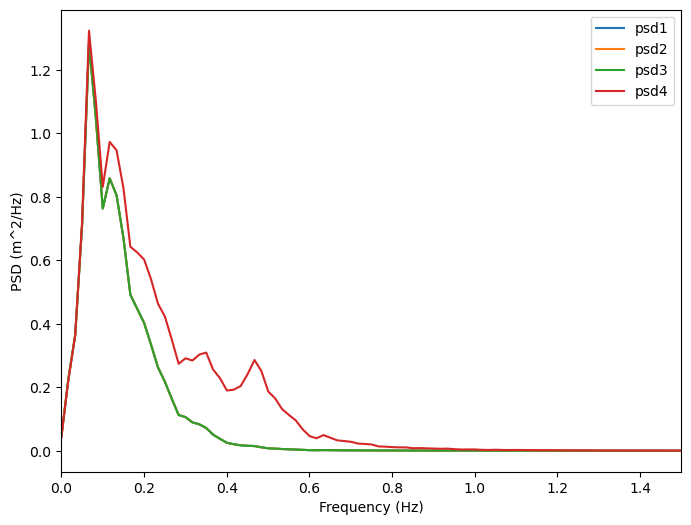

In [10]:


#f, psd = welch(z_filtered.values.squeeze(), fs=ds0.sf.values, nperseg=nperseg, detrend='constant', window='hann') # Detrend: is per segment. 1min, about constant, so false used

# plot ds_out.f vs ds_out.psd
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(f, psd1 / 1e8  )
ax.plot(f, psd2  / 1e8)
ax.plot(f, psd3  / 1e8)
ax.plot(f, psd4  )

#ax.plot(f, psd4b  )
#ax.plot(f, psd5  )

ax.set_xlim(0,1.5)
ax.legend(['psd1', 'psd2', 'psd3', 'psd4', 'psd4b', 'psd5'])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (m^2/Hz)')

f.shape

In [84]:
z_filtered.values.squeeze()

array([1.36526979, 1.66002923, 1.91721217, ..., 0.53532243, 0.74716968,
       1.01799725], shape=(19200,))

In [ ]:
# Determine wave parameters ---------------------------
ufunc_wave_params = lambda psd: puv.compute_wave_params(ds_2D.f.values, psd, fmin=0.004 , fmax=5)   

ds_out['Hm0'], ds_out['Tp'], ds_out['Tm01'], ds_out['Tm02'], ds_out['Tmm10'], ds_out['Tps'] = xr.apply_ufunc(ufunc_wave_params,
                                                                        ds_2D['psd'],
                                                                        input_core_dims=[['f']],
                                                                        output_core_dims=[[], [], [], [], [], []],
                                                                        vectorize=True)
ds_out['Hm0_IG'], ds_out['Tp_IG'], ds_out['Tm01_IG'], ds_out['Tm02_IG'], ds_out['Tmm10_IG'], ds_out['Tps_IG'] = xr.apply_ufunc(ufunc_wave_params,
                                                                        ds_2D['psd_IG'],
                                                                        input_core_dims=[['f']],
                                                                        output_core_dims=[[], [], [], [], [], []],
                                                                        vectorize=True)

ds_out['Hm0'].attrs = ds_out['Hm0_IG'].attrs = {'units': 'm', 'long_name': 'significant wave height: Hm0=4sqrt(m0), with m0 zeroth-order spectral moment'}
ds_out['Tp'].attrs = ds_out['Tp_IG'].attrs = {'units': 's', 'long_name': 'peak wave period'}
ds_out['Tm01'].attrs = ds_out['Tm01_IG'].attrs = {'units': 's', 'long_name': 'mean wave period: Tm01 = m0/m1'}
ds_out['Tm02'].attrs = ds_out['Tm02_IG'].attrs = {'units': 's', 'long_name': 'mean zero-crossing period: Tm02 = sqrt(m0/m2)'}
ds_out['Tmm10'].attrs = ds_out['Tmm10_IG'].attrs = {'units': 's', 'long_name': 'T-1,0: mean absolute wave period T-1,0 = m_(-1)/m_0'}
ds_out['Tps'].attrs = ds_out['Tps_IG'].attrs = {'units': 's', 'long_name': 'Smoothed peak wave period'}

# Apply mask, to ensure NaNs where sensor is dry (zs was already made nan, but Tp etc. based on zs can still have values)
ds_out[['Hm0', 'Tp', 'Tm01', 'Tm02', 'Tmm10', 'Tps']] = ds_out[['Hm0', 'Tp', 'Tm01', 'Tm02', 'Tmm10', 'Tps']].where(~dry_mask_block, np.nan)
ds_out[['Hm0_IG', 'Tp_IG', 'Tm01_IG', 'Tm02_IG', 'Tmm10_IG', 'Tps_IG']] = ds_out[['Hm0_IG', 'Tp_IG', 'Tm01_IG', 'Tm02_IG', 'Tmm10_IG', 'Tps_IG']].where(~dry_mask_block, np.nan)